In [3]:
import os
import sys

os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/openjdk-17.jdk/Contents/Home"

from pyspark.sql import SparkSession
from dotenv import load_dotenv

load_dotenv()
cassandra_user = os.getenv("CASSANDRA_USER", "cassandra")
cassandra_password = os.getenv("CASSANDRA_PASSWORD", "cassandra")

# Inicializar Spark
spark = SparkSession.builder \
    .appName("Bluesky_OLAP_Processor") \
    .config("spark.jars.packages", "com.datastax.spark:spark-cassandra-connector_2.12:3.5.0") \
    .config("spark.cassandra.connection.host", "10.15.20.24") \
    .config("spark.cassandra.connection.port", "9041") \
    .config("spark.cassandra.auth.username", cassandra_user) \
    .config("spark.cassandra.auth.password", cassandra_password) \
    .config("spark.driver.extraJavaOptions", "-Djava.net.preferIPv4Stack=true") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
#print(f"Spark Inicializado con Java: {os.environ['JAVA_HOME']}")
print(f"Versión de Spark: {spark.version}")

Versión de Spark: 3.5.1


In [4]:
df_raw = spark.read \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="events", keyspace="jetstream_data") \
    .load()

print(f"Total de registros crudos en Cassandra: {df_raw.count()}")
df_raw.show(5, truncate=False)

Total de registros crudos en Cassandra: 391


+--------------------+----------------+--------------------------------+------+---------+-------------------------------------------------------------------------------------------------------------------------+-------------+
|collection          |time_us         |did                             |kind  |operation|record                                                                                                                   |rkey         |
+--------------------+----------------+--------------------------------+------+---------+-------------------------------------------------------------------------------------------------------------------------+-------------+
|app.bsky.graph.block|1776096831563348|did:plc:mqwehzxz3bveojr6uvwoho6f|commit|create   |{"$type": "app.bsky.graph.block", "createdAt": "2026-04-13T16:13:50.808Z", "subject": "did:plc:jrfwrlywcbyyabobofz6anmv"}|3mjfb4fivps2w|
|app.bsky.graph.block|1776096831479976|did:plc:7zfhsymgf7nrz3v6r73lyn3h|commit|create   |{"$type

In [13]:
from pyspark.sql.functions import col
from pyspark.sql import Row
import asyncio
import aiohttp
import redis
import requests
import nest_asyncio
from pyspark.sql.functions import col, get_json_object, to_timestamp, udf
from pyspark.sql.types import StringType

# --- 1. LIMPIEZA Y TRANSFORMACIÓN ---
df_clean = df_raw.withColumn("subject_did", get_json_object(col("record"), "$.subject")) \
                 .withColumn("timestamp", to_timestamp(col("time_us") / 1000000)) \
                 .select("collection", "timestamp", "operation", "did", "subject_did")

# --- 2. ENRIQUECIMIENTO (Resolución de DIDs PRO) ---

# 🔹 1. Obtener DIDs únicos
unique_dids = df_clean.select("did") \
    .union(df_clean.select("subject_did")) \
    .distinct() \
    .rdd.flatMap(lambda x: x) \
    .collect()

print(f"DIDs únicos encontrados: {len(unique_dids)}")


# 🔹 2. Configuración Redis
r = redis.Redis(host='localhost', port=6379, db=0, decode_responses=True)

BASE_URL = "https://bsky.social/xrpc/com.atproto.identity.resolveIdentity"


# 🔹 3. Separar cacheados vs faltantes
def split_cached_dids(dids):
    cached = {}
    missing = []

    for did in dids:
        if not did:
            continue
        val = r.get(did)
        if val:
            cached[did] = val
        else:
            missing.append(did)

    return cached, missing


# 🔹 4. Fetch async con control de concurrencia
async def fetch_handle(session, did, semaphore):
    url = f"https://plc.directory/{did}"

    async with semaphore:
        try:
            async with session.get(url, timeout=5) as resp:
                if resp.status == 200:
                    data = await resp.json()
                    #print(data)
                    
                    aka = data.get("alsoKnownAs", [])
                    if aka:
                        handle = aka[0].replace("at://", "")
                        return did, handle
                    
                    return did, did
                else:
                    return did, did
        except:
            return did, did


# 🔹 5. Resolver en paralelo
async def resolve_all_dids(dids, max_concurrent=20):
    connector = aiohttp.TCPConnector(limit=50)
    timeout = aiohttp.ClientTimeout(total=10)
    semaphore = asyncio.Semaphore(max_concurrent)

    async with aiohttp.ClientSession(connector=connector, timeout=timeout) as session:
        tasks = [fetch_handle(session, did, semaphore) for did in dids]
        results = await asyncio.gather(*tasks)

    return dict(results)


# 🔹 6. Guardar en Redis
def save_to_cache(did_map):
    for did, handle in did_map.items():
        if handle:
            r.setex(did, 86400, handle)  # TTL 1 día


# 🔹 7. Pipeline completo
def resolve_dids_pro(dids):
    cached, missing = split_cached_dids(dids)

    print(f"Cache hits: {len(cached)} | Missing: {len(missing)}")

    if missing:
        
        nest_asyncio.apply()

        loop = asyncio.get_event_loop()
        resolved = loop.run_until_complete(resolve_all_dids(missing))

        save_to_cache(resolved)
    else:
        resolved = {}

    return {**cached, **resolved}


# 🔹 8. Ejecutar resolución
did_map = resolve_dids_pro(unique_dids)


# 🔹 9. Convertir a DataFrame
did_rows = [Row(did=k, handle=v) for k, v in did_map.items()]
df_did_map = spark.createDataFrame(did_rows)


# 🔹 10. Joins (actor + subject)
df_enriched = df_clean \
    .join(df_did_map.withColumnRenamed("did", "actor_did")
                     .withColumnRenamed("handle", "actor_handle"),
          df_clean.did == col("actor_did"), "left") \
    .join(df_did_map.withColumnRenamed("did", "subject_did_join")
                     .withColumnRenamed("handle", "subject_handle"),
          df_clean.subject_did == col("subject_did_join"), "left")


# 🔹 11. Resultado final
df_final = df_enriched.select(
    "timestamp",
    "collection",
    "operation",
    "actor_handle",
    "subject_handle"
)

df_final.show(10, truncate=False)

DIDs únicos encontrados: 629
Cache hits: 628 | Missing: 0


+--------------------------+--------------------+---------+----------------------------+----------------------------+
|timestamp                 |collection          |operation|actor_handle                |subject_handle              |
+--------------------------+--------------------+---------+----------------------------+----------------------------+
|2026-04-13 10:13:48.767916|app.bsky.graph.block|create   |freehiker74.bsky.social     |tjaysixty4.bsky.social      |
|2026-04-13 10:13:49.987668|app.bsky.graph.block|delete   |papajohndomino.bsky.social  |NULL                        |
|2026-04-13 10:13:49.360681|app.bsky.graph.block|create   |stefanhar.bsky.social       |vielaine.bsky.social        |
|2026-04-13 10:13:51.479976|app.bsky.graph.block|create   |bee-01.bsky.social          |betty6124785.bsky.social    |
|2026-04-13 10:13:49.31157 |app.bsky.graph.block|create   |friorox.bsky.social         |minifork.bsky.social        |
|2026-04-13 10:13:51.563348|app.bsky.graph.block|create 

In [14]:
from pyspark.sql.functions import col, window, desc, count, when, row_number
from pyspark.sql.window import Window

print("--- INICIANDO ANÁLISIS DE RESULTADOS ---")

# Filtrar nulos para los análisis que requieren un receptor (subject)
df_valid_subjects = df_final.filter(col("subject_handle").isNotNull())

# ---------------------------------------------------------
# CONSULTA 1: Tendencia de Actividad (Time-Series Aggregation)
# Muestra el volumen de eventos (Follows vs Blocks) por ventanas de 1 minuto.
# Útil para detectar picos de actividad o anomalías en el stream.
# ---------------------------------------------------------
print("\n1. Tendencia de Actividad por Minuto:")
df_trend = df_final.groupBy(
    window(col("timestamp"), "1 minute"), 
    col("collection")
).count().orderBy(col("window.start").desc())

df_trend.show(5, truncate=False)

# ---------------------------------------------------------
# CONSULTA 2: Identificación de "Spammers" o Cuentas Altamente Activas
# Agregación masiva para encontrar quiénes están dando más follows o blocks.
# (Centralidad de Grado de Salida / Out-Degree en grafos)
# ---------------------------------------------------------
print("\n2. Usuarios Más Activos (Out-Degree):")
df_active_actors = df_final.groupBy("actor_handle") \
                           .count() \
                           .orderBy(desc("count"))

df_active_actors.show(5, truncate=False)

# ---------------------------------------------------------
# CONSULTA 3: Top Influencers y Cuentas Polémicas
# ¿Quiénes están recibiendo más interacciones? 
# (Centralidad de Grado de Entrada / In-Degree)
# ---------------------------------------------------------
print("\n3. Usuarios Más Receptores (In-Degree):")
df_top_targets = df_valid_subjects.groupBy("subject_handle", "collection") \
                                  .count() \
                                  .orderBy(desc("count"))

df_top_targets.show(5, truncate=False)

# ---------------------------------------------------------
# CONSULTA 4: Proporción de Sentimiento de la Red (Follows vs Blocks)
# Uso de agregación condicional para evaluar el "humor" del stream capturado.
# ---------------------------------------------------------
print("\n4. Proporción General de Interacciones:")
df_ratio = df_final.groupBy().agg(
    count(when(col("collection") == "app.bsky.graph.follow", True)).alias("Total_Follows"),
    count(when(col("collection") == "app.bsky.graph.block", True)).alias("Total_Blocks"),
    count("*").alias("Total_Eventos")
)

df_ratio.show(truncate=False)

# ---------------------------------------------------------
# CONSULTA 5: Líderes por Categoría (Window Functions)
# Consulta compleja que particiona los datos por tipo de evento y obtiene 
# el "Top 3" de usuarios más impactados en cada categoría (Follow y Block).
# ---------------------------------------------------------
print("\n5. Top 3 Usuarios Receptores Particionado por Colección (Window Function):")
windowSpec = Window.partitionBy("collection").orderBy(desc("count"))

df_ranked_targets = df_valid_subjects.groupBy("collection", "subject_handle").count() \
                                     .withColumn("rank", row_number().over(windowSpec))

df_top_3_per_category = df_ranked_targets.filter(col("rank") <= 3).orderBy("collection", "rank")

df_top_3_per_category.show(truncate=False)

--- INICIANDO ANÁLISIS DE RESULTADOS ---

1. Tendencia de Actividad por Minuto:


+------------------------------------------+---------------------+-----+
|window                                    |collection           |count|
+------------------------------------------+---------------------+-----+
|{2026-04-13 10:13:00, 2026-04-13 10:14:00}|app.bsky.graph.follow|194  |
|{2026-04-13 10:13:00, 2026-04-13 10:14:00}|app.bsky.graph.block |26   |
|{2026-04-06 17:26:00, 2026-04-06 17:27:00}|app.bsky.graph.block |16   |
|{2026-04-06 17:26:00, 2026-04-06 17:27:00}|app.bsky.graph.follow|155  |
+------------------------------------------+---------------------+-----+


2. Usuarios Más Activos (Out-Degree):


+---------------------------+-----+
|actor_handle               |count|
+---------------------------+-----+
|nakedgaystonerr.bsky.social|13   |
|winemommystery.bsky.social |11   |
|anna76-79.bsky.social      |9    |
|myqueerfans.bsky.social    |9    |
|podcastgreenred.bsky.social|7    |
+---------------------------+-----+
only showing top 5 rows


3. Usuarios Más Receptores (In-Degree):


+-----------------------------+---------------------+-----+
|subject_handle               |collection           |count|
+-----------------------------+---------------------+-----+
|bsky.app                     |app.bsky.graph.follow|3    |
|ldog562.bsky.social          |app.bsky.graph.follow|1    |
|l3fundacion.bsky.social      |app.bsky.graph.follow|1    |
|karkos53.bsky.social         |app.bsky.graph.follow|1    |
|satansmydaddyrawr.bsky.social|app.bsky.graph.block |1    |
+-----------------------------+---------------------+-----+
only showing top 5 rows


4. Proporción General de Interacciones:


+-------------+------------+-------------+
|Total_Follows|Total_Blocks|Total_Eventos|
+-------------+------------+-------------+
|349          |42          |391          |
+-------------+------------+-------------+


5. Top 3 Usuarios Receptores Particionado por Colección (Window Function):


+---------------------+---------------------------+-----+----+
|collection           |subject_handle             |count|rank|
+---------------------+---------------------------+-----+----+
|app.bsky.graph.block |em.ily.dev                 |1    |1   |
|app.bsky.graph.block |firstonmorefost.bsky.social|1    |2   |
|app.bsky.graph.block |the-art-of-web.com         |1    |3   |
|app.bsky.graph.follow|bsky.app                   |3    |1   |
|app.bsky.graph.follow|giannispriftis.bsky.social |1    |2   |
|app.bsky.graph.follow|ojusfzc.bsky.social        |1    |3   |
+---------------------+---------------------------+-----+----+



--- GENERANDO VISUALIZACIONES ANALÍTICAS ---
1. Graficando Proporción de Interacciones...


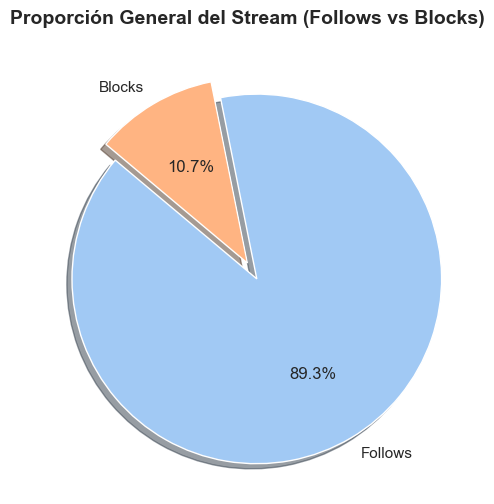

2. Graficando Tendencia de Actividad...


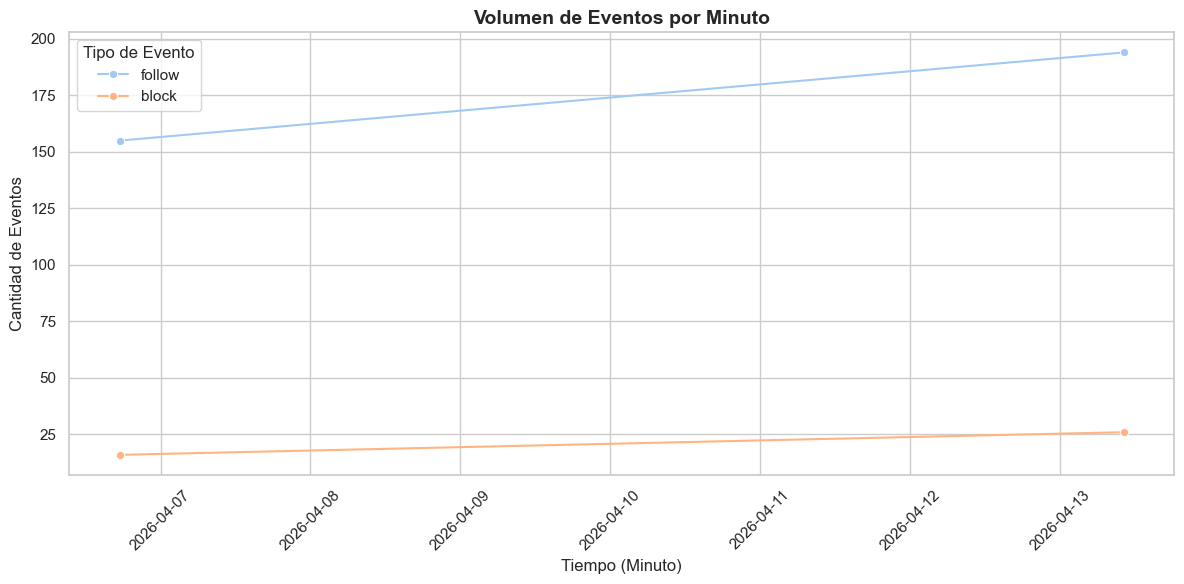

3. Graficando Top Usuarios Activos...


/var/folders/8r/lpfr7zcx7g5fd8bxyg6xysyw0000gn/T/ipykernel_4103/4094896077.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_active, x='count', y='actor_handle', palette='viridis')


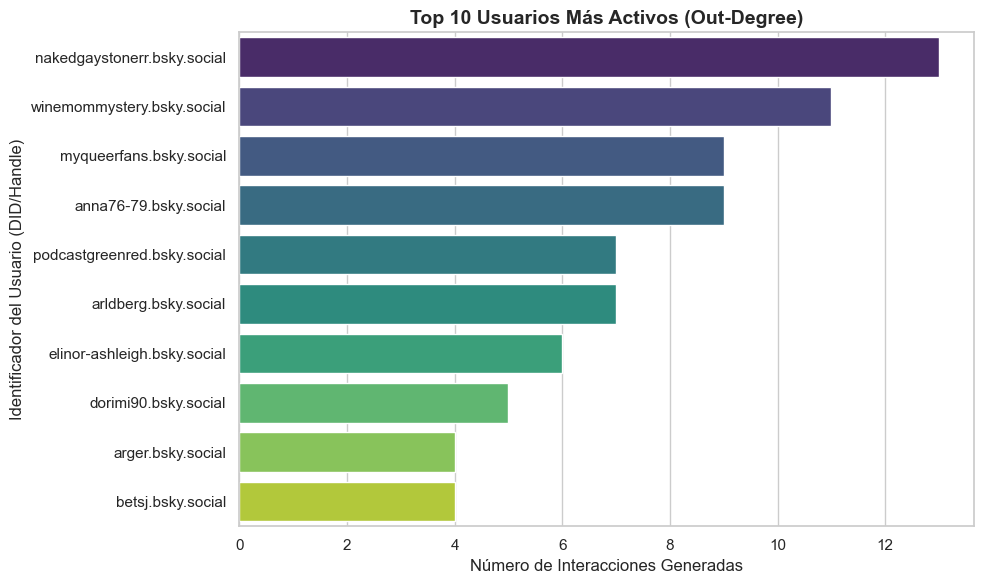

¡Gráficas generadas y guardadas como imágenes PNG en tu directorio!


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)

print("--- GENERANDO VISUALIZACIONES ANALÍTICAS ---")

# ==========================================
# Gráfica 1: Proporción de Interacciones (Pie Chart)
# Representa la "Consulta 4"
# ==========================================
print("1. Graficando Proporción de Interacciones...")
pd_ratio = df_ratio.toPandas()

labels = ['Follows', 'Blocks']
sizes = [pd_ratio['Total_Follows'][0], pd_ratio['Total_Blocks'][0]]
colors = sns.color_palette('pastel')[0:2]
explode = (0.1, 0) 

plt.figure()
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Proporción General del Stream (Follows vs Blocks)', fontsize=14, fontweight='bold')
plt.savefig('grafica_proporcion.png', bbox_inches='tight') # Guardar para el README
plt.show()

# ==========================================
# Gráfica 2: Tendencia de Actividad en el Tiempo (Line Plot)
# Representa la "Consulta 1"
# ==========================================
print("2. Graficando Tendencia de Actividad...")
pd_trend = df_trend.toPandas()

# Limpiar los datos para graficar: Extraer el inicio de la ventana y renombrar colecciones
pd_trend['timestamp'] = pd_trend['window'].apply(lambda x: x['start'])
pd_trend['collection'] = pd_trend['collection'].str.replace('app.bsky.graph.', '')

plt.figure(figsize=(12, 6))
sns.lineplot(data=pd_trend, x='timestamp', y='count', hue='collection', marker='o')
plt.title('Volumen de Eventos por Minuto', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Minuto)', fontsize=12)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Tipo de Evento')
plt.tight_layout()
plt.savefig('grafica_tendencia.png') # Guardar para el README
plt.show()

# ==========================================
# Gráfica 3: Usuarios Más Activos (Bar Chart Horizontal)
# Representa la "Consulta 2"
# ==========================================
print("3. Graficando Top Usuarios Activos...")
pd_active = df_active_actors.limit(10).toPandas()

plt.figure()
sns.barplot(data=pd_active, x='count', y='actor_handle', palette='viridis')
plt.title('Top 10 Usuarios Más Activos (Out-Degree)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Interacciones Generadas', fontsize=12)
plt.ylabel('Identificador del Usuario (DID/Handle)', fontsize=12)
plt.tight_layout()
plt.savefig('grafica_activos.png') # Guardar para el README
plt.show()

print("¡Gráficas generadas y guardadas como imágenes PNG en tu directorio!")